# MFM FISHER

In [1]:
from simu_PSF_polarMFM import *
from fisher_4pMFM import *
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import re
from tqdm import tqdm
import os

In [2]:
NPSF = 400
device='cuda'

In [3]:
N_photons=5000 # number of photons collected 
N=80 # discretization of the BFP
l_pixel=16 #pixel size in micrometer
NA=1.4 # numerical aperture
mag=100 # first magnification
lambd=617 # wavelength in nm
f_tube=200 # tube lens focal in mm
MAG=200/150 # second magnification

N_photons=torch.tensor(N_photons, device=device)
N=torch.tensor(N, device=device)
l_pixel=torch.tensor(l_pixel, device=device)
NA=torch.tensor(NA, device=device)
mag=torch.tensor(mag, device=device)
lambd=torch.tensor(lambd, device=device)
f_tube=torch.tensor(f_tube, device=device)
MAG=torch.tensor(MAG, device=device)

In [4]:
xp=torch.tensor(np.random.rand(NPSF)*0.1, device=device)
yp=torch.tensor(np.random.rand(NPSF)*0.1, device=device)
z=torch.tensor(np.random.rand(NPSF)*1.+1., device=device)
d_=torch.tensor([-2. for i in range(NPSF)], device=device)
rho = torch.tensor([45 for k in range(NPSF)], device=device)
eta = torch.tensor([45 for k in range(NPSF)], device=device)
delta = torch.tensor([80 for k in range(NPSF)], device=device)
second_plane = torch.tensor([-0.365, 0, 0.365])
zernike_coefs_x = torch.zeros((3,15), device=device)
zernike_coefs_y = torch.zeros((3,15), device=device)
polar_projections = np.array([0, 45, 0])

In [5]:
J1 = np.array([[ 0.89642966        ,             -0.15750188 + 1j*  -0.41388938 ],[
      -0.22662663 + 1j*  0.37517267  ,   -0.88134384 + 1j*  -0.17010298 ]])
J2 = np.array([[ 0.5655862               ,      -0.77402043 + 1j*  0.27935567 ],[
      0.42339513 + 1j*  -0.7021969   ,  0.11452306 + 1j*  -0.5653576 ]])
J = np.array([J1, J2, J1])

J = np.array([[1,0],[0,1]])

In [6]:
SAF = False

In [7]:
if SAF:
    x, y, th1, phi, [Ex0, Ex1, Ex2], [Ey0, Ey1, Ey2], r, r_cut, r_cut_saf, k, f_o, costh2 = vectorial_BFP_perfect_focus(N, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, SAF=SAF, device=device, J_dichroic=J)
else:
    costh2=None
    x, y, th1, phi, [Ex0, Ex1, Ex2], [Ey0, Ey1, Ey2], r, r_cut, k, f_o = vectorial_BFP_perfect_focus(N, NA=NA, mag=mag, lambd=lambd, f_tube=f_tube, SAF=SAF, device=device, J_dichroic=J)

/mnt/c/Users/Amaury/Documents/GitHub/4polarMFM_these/simu_PSF_polarMFM.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  costh2 = costh2.astype(float)


In [8]:
phase_mask=torch.ones((N,N)) #np.exp(1j*phi)
phase_mask[x**2+y**2>r_cut**2]=1.

phase_mask = torch.stack([torch.ones((N,N), device=device), torch.tensor(phase_mask, device=device), torch.ones((N,N), device=device)])
zernike_base = generate_zernike_base(r_cut=r_cut, N=N, zernike_order=4, device=device)

/tmp/ipykernel_8868/3780356185.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phase_mask = torch.stack([torch.ones((N,N), device=device), torch.tensor(phase_mask, device=device), torch.ones((N,N), device=device)])


In [9]:
u, v, Npadding = padding(r, r_cut, k, f_o, N=N, l_pixel=l_pixel, NA=NA, mag=mag, lambd=lambd, 
              f_tube=f_tube, MAG=MAG, device=device)
print(Npadding)

tensor(74, device='cuda:0')


/home/amaury/exit/envs/env_linux/lib/python3.10/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4382.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [10]:
th1 = pad(th1, Npadding)
phi = pad(phi, Npadding)
Ex0 = pad(Ex0, Npadding)
Ex1 = pad(Ex1, Npadding)
Ex2 = pad(Ex2, Npadding)
Ey0 = pad(Ey0, Npadding)
Ey1 = pad(Ey1, Npadding)
Ey2 = pad(Ey2, Npadding)
phase_mask = pad(phase_mask, Npadding)
zernike_base = pad(zernike_base, Npadding)
if SAF:
    costh2 = pad(costh2, Npadding)

In [11]:
phase_mask.shape

torch.Size([3, 154, 154])

In [12]:
M = compute_M(xp=xp, yp=yp, zp=z, d=d_, x=x, y=y, th1=th1, phi=phi, Ex0=Ex0, Ex1=Ex1, Ex2=Ex2,
                    Ey0=Ey0, Ey1=Ey1, Ey2=Ey2, r=r, r_cut=r_cut, k=k, f_o=f_o,
                    phase_maskx=phase_mask, phase_masky=phase_mask, zernike_base=zernike_base, zernike_coefs_x=zernike_coefs_x, 
                    zernike_coefs_y=zernike_coefs_x, second_plane=second_plane, polar_projections=polar_projections, lambd=lambd, f_tube=f_tube, 
                    BFP_version=False, SAF=SAF, costh2=costh2)

In [13]:
psf = PSF(rho=rho, eta=eta, delta=delta, M=M, N_photons=N_photons)

In [71]:
RHO = torch.tensor(np.random.rand(NPSF)*2*np.pi, device=device)
ETA = torch.tensor(np.arccos(np.random.uniform(np.cos(0*np.pi/180), np.cos(90*np.pi/180), NPSF)), device=device)
DELTA = torch.tensor(40*np.pi/180+np.random.rand(NPSF)*(110*np.pi/180), device=device)#torch.tensor([70 for uu in range(NPSF)], device=device)#torch.tensor(0.0001*np.random.rand(NPSF), device=device)#
N = torch.tensor([5000 for uu in range(NPSF)], device=device)#torch.tensor((2000+np.random.rand(NPSF)*6000), device=device)#*(torch.sin(ETA)**2)
bck = torch.tensor(300, device=device)

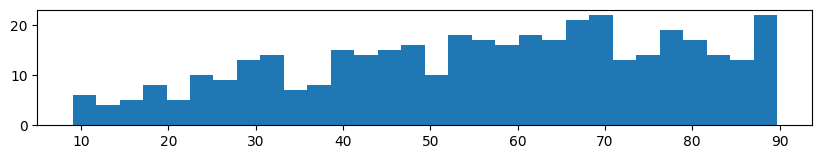

In [72]:
u = plt.hist(ETA.cpu().numpy()*180/np.pi, bins=30)

In [73]:
F = fisher(M, RHO, ETA, DELTA, N, bck)

In [74]:
F = torch.mean(F, dim=2)
print(F.cpu().detach().numpy())

[[121.04102568   0.66719241  -2.94670019]
 [  0.66719241  97.39277932 -25.71093145]
 [ -2.94670019 -25.71093145 121.35643795]]


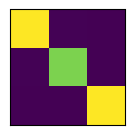

In [75]:
plt.imshow(F.cpu().detach().numpy(), vmin=0)
plt.xticks([])
plt.yticks([])
plt.show()

In [76]:
#torch.sqrt(F)*(180/np.pi)
torch.sqrt(torch.linalg.inv(F))*(180/np.pi)

tensor([[5.2094,    nan, 0.8101],
        [   nan, 5.9753, 2.7503],
        [0.8101, 2.7503, 5.3544]], device='cuda:0', dtype=torch.float64)

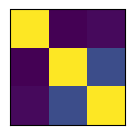

In [77]:
S = torch.inverse(F)
s = torch.diagonal(S)
CORR = S/torch.sqrt(torch.einsum('i,j->ij', s, s))
plt.imshow(CORR.cpu().detach().numpy(), vmin=0, vmax=1)
plt.xticks([])
plt.yticks([])
plt.show()

# On ratiometric 

In [78]:
F = fisher_ratiometric(M, RHO, ETA, DELTA, N, bck)

In [79]:
F = torch.mean(F, dim=2)

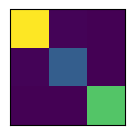

In [80]:
plt.imshow(F.cpu().detach().numpy(), vmin=0)
plt.xticks([])
plt.yticks([])
plt.show()

In [81]:
torch.sqrt(torch.inverse(F))*(180/np.pi)

tensor([[ 5.2801,  0.8514,  1.1485],
        [ 0.8514, 14.1515,  9.6459],
        [ 1.1485,  9.6459,  9.0149]], device='cuda:0', dtype=torch.float64)

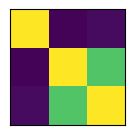

In [82]:
S = torch.inverse(F)
s = torch.diagonal(S)
CORR = S/torch.sqrt(torch.einsum('i,j->ij', s, s))
plt.imshow(CORR.cpu().detach().numpy(), vmin=0, vmax=1)
plt.xticks([])
plt.yticks([])
plt.show()

## WRT to eta

In [83]:
eta_list = np.linspace(0,180,40)
eta_plot = (eta_list[1:]+eta_list[:-1])/2

In [29]:
cr_rho = []
cr_eta = []
cr_delta = []
cr_rho_r = []
cr_eta_r = []
cr_delta_r = []
for i, eta_lim in tqdm(enumerate(eta_list[:-1])):
    RHO = torch.tensor(np.random.rand(NPSF)*2*np.pi, device=device)
    ETA = torch.tensor(np.arccos(np.random.uniform(np.cos(eta_lim*np.pi/180), np.cos(eta_list[i+1]*np.pi/180), NPSF)), device=device)
    #plt.hist(ETA.cpu().numpy()*180/np.pi, bins=30)
    #plt.show()
    DELTA = torch.tensor(89*np.pi/180+np.random.rand(NPSF)*(2*np.pi/180), device=device)#torch.tensor(40*np.pi/180+np.random.rand(NPSF)*(110*np.pi/180), device=device)# 
    N = torch.tensor((5000*np.array([1 for iii in range(NPSF)])), device=device)#torch.tensor((2000+np.random.rand(NPSF)*6000), device=device)#*(torch.sin(ETA)**2)
    bck = torch.tensor(0., device=device)
    F = fisher(M, RHO, ETA, DELTA, N, bck)
    Fr = fisher_ratiometric(M, RHO, ETA, DELTA, N, bck)
    cr = torch.sqrt(torch.inverse(torch.mean(F, dim=2)))*(180/np.pi)
    crr = torch.sqrt(torch.inverse(torch.mean(Fr, dim=2)))*(180/np.pi)
    #print(cr)
    cr_rho.append(cr[0,0].cpu().numpy())
    cr_eta.append(cr[1,1].cpu().numpy())
    cr_delta.append(cr[2,2].cpu().numpy())
    #print(cr_rho, cr_eta, cr_delta)
    cr_rho_r.append(crr[0,0].cpu().numpy())
    cr_eta_r.append(crr[1,1].cpu().numpy())
    cr_delta_r.append(crr[2,2].cpu().numpy())
    #print(cr_rho_r, cr_eta_r, cr_delta_r)

39it [00:20,  1.94it/s]


In [31]:
folder = '/mnt/c/Users/Amaury/Documents/GitHub/4polarMFM_these/files_papier/no_noise_delta90_start_90_300steps/'
x_true = []
y_true = []
z_true = []
rho_true = []
eta_true = []
delta_true = []
N_true = []
x_found = []
y_found = []
z_found = []
rho_found = []
eta_found = []
delta_found = []
N_found = []
pattern = re.compile(r"eta_([-+]?\d*\.?\d+)_rho_([-+]?\d*\.?\d+)")

files = sorted(
    os.listdir(folder),
    key=lambda f: (
        float(pattern.search(f).group(1)),  # eta
        float(pattern.search(f).group(2))   # rho
    )
)

for filename in files:
    data = np.load(os.path.join(folder, filename))
    x_true.append(data['x_true'])
    y_true.append(data['y_true'])
    z_true.append(data['z_true'])
    rho_true.append(data['rho_true'])
    eta_true.append(data['eta_true'])
    delta_true.append(data['delta_true'])
    N_true.append(data['N_true'])
    x_found.append(data['x_found'])
    y_found.append(data['y_found'])
    z_found.append(data['z_found'])
    rho_found.append(data['rho_found'])
    eta_found.append(data['eta_found'])
    delta_found.append(data['delta_found'])
    N_found.append(data['N_found'])
nnn = 20
x_true = np.array(x_true).reshape(nnn,nnn,100)
y_true = np.array(y_true).reshape(nnn,nnn,100)
z_true = np.array(z_true).reshape(nnn,nnn,100)
rho_true = np.array(rho_true).reshape(nnn,nnn,100)
eta_true = np.array(eta_true).reshape(nnn,nnn,100)
delta_true = np.array(delta_true).reshape(nnn,nnn,100)
N_true = np.array(N_true).reshape(nnn,nnn,100)
x_found = np.array(x_found).reshape(nnn,nnn,100)
y_found = np.array(y_found).reshape(nnn,nnn,100)
z_found = np.array(z_found).reshape(nnn,nnn,100)
rho_found = np.array(rho_found).reshape(nnn,nnn,100)%360
eta_found = np.array(eta_found).reshape(nnn,nnn,100)%180
delta_found = np.array(delta_found).reshape(nnn,nnn,100)
N_found = np.array(N_found).reshape(nnn,nnn,100)

In [32]:
mask0 = (rho_found>180) | (rho_found<0)
rho_found[mask0] = rho_found[mask0]%180
eta_found[mask0] = 180-(eta_found[mask0])
deltax = x_found-x_true
deltay = y_found-y_true
deltaz = z_found - z_true
deltarho = rho_found - rho_true
deltadelta = delta_found-delta_true
deltaN = N_found-N_true
mask1 = deltarho > 90
deltarho[mask1] = deltarho[mask1]-180
mask2 = deltarho < -90
deltarho[mask2] = deltarho[mask2]+180
eta_found[mask1] = 180-eta_found[mask1]
eta_found[mask2] = 180-eta_found[mask2]
deltaeta = eta_found-eta_true
mask1 = deltaeta > 90
deltaeta[mask1] = deltaeta[mask1]-180
mask2 = deltaeta < -90
deltaeta[mask2] = deltaeta[mask2]+180

In [33]:
eta_listMC = np.linspace(0.1, 179.9, 20)

(0.0, 15.0)

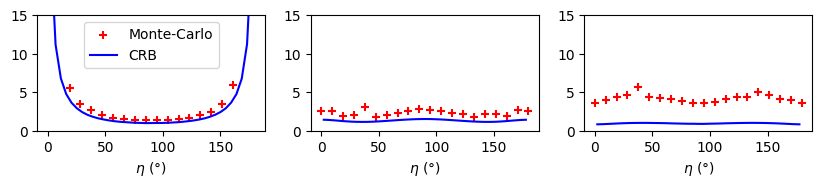

In [49]:
plt.rcParams['figure.figsize'] = [10, 1.5]
fig, ax = plt.subplots(1,3)
mesh = ax[0].scatter(eta_listMC, np.mean(np.nanstd(deltarho, axis=2).T, axis=0), marker='+', c='r', label='Monte-Carlo')
ax[0].plot(eta_plot, cr_rho, c='b', label='CRB')
ax[0].set_xlabel('$\\eta$ ($\\degree$)')
#ax[0].set_ylabel('$\\sigma$ ($\\degree$)')
ax[0].legend()
ax[0].set_ylim((0,15))

mesh = ax[1].scatter(eta_listMC, np.mean(np.nanstd(deltaeta, axis=2).T, axis=0), marker='+', c='r')
ax[1].plot(eta_plot, cr_eta, c='b', label='CRB')
ax[1].set_xlabel('$\\eta$ ($\\degree$)')
#ax[1].set_ylabel('$\\sigma$ ($\\degree$)')
ax[1].set_ylim((0,15))

mesh = ax[2].scatter(eta_listMC, np.mean(np.nanstd(deltadelta, axis=2).T, axis=0), marker='+', c='r')
ax[2].plot(eta_plot, cr_delta, c='b', label='CRB')
ax[2].set_xlabel('$\\eta$ ($\\degree$)')
#ax[2].set_ylabel('$\\sigma$ ($\\degree$)')
ax[2].set_ylim((0,15))
#plt.savefig("std_orientation.svg", format="svg")

In [32]:
cr_rho2 = cr_rho
cr_eta2 = cr_eta 
cr_delta2 = cr_delta
cr_rho_r2 = cr_rho_r
cr_eta_r2 = cr_eta_r
cr_delta_r2 = cr_delta_r

In [33]:
cr_rho3 = cr_rho
cr_eta3 = cr_eta 
cr_delta3 = cr_delta
cr_rho_r3 = cr_rho_r
cr_eta_r3 = cr_eta_r
cr_delta_r3 = cr_delta_r

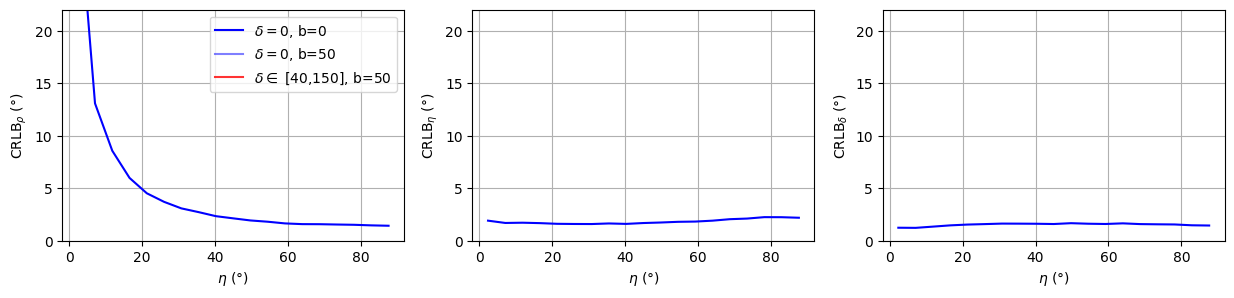

In [52]:
plt.rcParams['figure.figsize'] = [15,3]
fig, ax = plt.subplots(1,3)
ax[0].plot(eta_plot, cr_rho, c='b', label='$\\delta=0$, b=0')
ax[0].plot(eta_plot, cr_rho2, c='b', alpha=0.5, label='$\\delta=0$, b=50')
ax[0].plot(eta_plot, cr_rho3, c='r', alpha=0.8, label='$\\delta \\in$ [40,150], b=50')
ax[0].legend()
#ax[0].set_yscale('log')
ax[0].set_xlabel('$\\eta$ ($\\degree$)')
ax[0].set_ylabel('CRLB$_{\\rho}$ ($\\degree$)')
ax[0].set_ylim((0,22))
ax[0].grid()
ax[1].plot(eta_plot, cr_eta, c='b')
ax[1].plot(eta_plot, cr_eta2, c='b', alpha=0.5)
ax[1].plot(eta_plot, cr_eta3, c='r', alpha=0.8)
#ax[1].axhline(3.6)
#ax[1].set_yscale('log')
ax[1].set_xlabel('$\\eta$ ($\\degree$)')
ax[1].set_ylabel('CRLB$_{\\eta}$ ($\\degree$)')
ax[1].set_ylim((0,22))
ax[1].grid()
ax[2].plot(eta_plot, cr_delta, c='b')
#ax[2].plot(eta_plot, cr_delta2, c='b', alpha=0.5)
#ax[2].plot(eta_plot, cr_delta3, c='r', alpha=0.8)
#ax[2].set_yscale('log')
ax[2].set_xlabel('$\\eta$ ($\\degree$)')
ax[2].set_ylabel('CRLB$_{\\delta}$ ($\\degree$)')
ax[2].set_ylim((0,22))
ax[2].grid()

In [ ]:
plt.rcParams['figure.figsize'] = [15,3]
fig, ax = plt.subplots(1,3)
ax[0].plot(eta_plot, cr_rho_r, c='b', label='$\\delta=0$, b=0')
ax[0].plot(eta_plot, cr_rho_r2, c='b', alpha=0.5, label='$\\delta=0$, b=50')
ax[0].plot(eta_plot, cr_rho_r3, c='r', alpha=0.8, label='$\\delta \\in$ [40,150], b=50')
ax[0].legend()
#ax[0].set_yscale('log')
ax[0].set_xlabel('$\\eta$ ($\\degree$)')
ax[0].set_ylabel('CRLB$_{\\rho}$ ($\\degree$)')
ax[0].set_ylim((0,22))
ax[0].grid()
ax[1].plot(eta_plot, cr_eta_r, c='b')
ax[1].plot(eta_plot, cr_eta_r2, c='b', alpha=0.5)
ax[1].plot(eta_plot, cr_eta_r3, c='r', alpha=0.8)
#ax[1].axhline(3.6)
#ax[1].set_yscale('log')
ax[1].set_xlabel('$\\eta$ ($\\degree$)')
ax[1].set_ylabel('CRLB$_{\\eta}$ ($\\degree$)')
ax[1].set_ylim((0,22))
ax[1].grid()
#ax[2].plot(eta_plot, cr_delta_r, c='b')
#ax[2].plot(eta_plot, cr_delta_r2, c='b', alpha=0.5)
ax[2].plot(eta_plot, cr_delta_r3, c='r', alpha=0.8)
#ax[2].set_yscale('log')
ax[2].set_xlabel('$\\eta$ ($\\degree$)')
ax[2].set_ylabel('CRLB$_{\\delta}$ ($\\degree$)')
ax[2].set_ylim((0,22))
ax[2].grid()

In [50]:
rho_list = np.linspace(0,90,20)
rho_plot = (eta_list[1:]+eta_list[:-1])/2

In [ ]:
cr_rho = []
cr_eta = []
cr_delta = []
cr_rho_r = []
cr_eta_r = []
cr_delta_r = []
for i, rho_lim in tqdm(enumerate(rho_list[:-1])):
    RHO = torch.tensor(np.random.uniform(rho_lim, rho_list[i+1]), device=device)
    ETA = torch.tensor(np.arccos(np.random.uniform(np.cos(20*np.pi/180), np.cos(90*np.pi/180), NPSF)), device=device)
    #plt.hist(ETA.cpu().numpy()*180/np.pi, bins=30)
    #plt.show()
    DELTA = torch.tensor(80*np.pi/180+np.random.rand(NPSF)*(10*np.pi/180), device=device)#torch.tensor(0.1*np.random.rand(NPSF), device=device)# 
    N = torch.tensor((5000*np.array([1 for iii in range(NPSF)])), device=device)#*(torch.sin(ETA)**2)
    bck = torch.tensor(0., device=device)
    F = fisher(M, RHO, ETA, DELTA, N, bck)
    Fr = fisher_ratiometric(M, RHO, ETA, DELTA, N, bck)
    cr = torch.sqrt(torch.inverse(torch.mean(F, dim=2)))*(180/np.pi)
    crr = torch.sqrt(torch.inverse(torch.mean(Fr, dim=2)))*(180/np.pi)
    #print(cr)
    cr_rho.append(cr[0,0].cpu().numpy())
    cr_eta.append(cr[1,1].cpu().numpy())
    cr_delta.append(cr[2,2].cpu().numpy())
    #print(cr_rho, cr_eta, cr_delta)
    cr_rho_r.append(crr[0,0].cpu().numpy())
    cr_eta_r.append(crr[1,1].cpu().numpy())
    cr_delta_r.append(crr[2,2].cpu().numpy())
    #print(cr_rho_r, cr_eta_r, cr_delta_r)

In [47]:
cr_rho2 = cr_rho
cr_eta2 = cr_eta 
cr_delta2 = cr_delta
cr_rho_r2 = cr_rho_r
cr_eta_r2 = cr_eta_r
cr_delta_r2 = cr_delta_r

In [48]:
cr_rho3 = cr_rho
cr_eta3 = cr_eta 
cr_delta3 = cr_delta
cr_rho_r3 = cr_rho_r
cr_eta_r3 = cr_eta_r
cr_delta_r3 = cr_delta_r

NameError: name 'rho_plot' is not defined

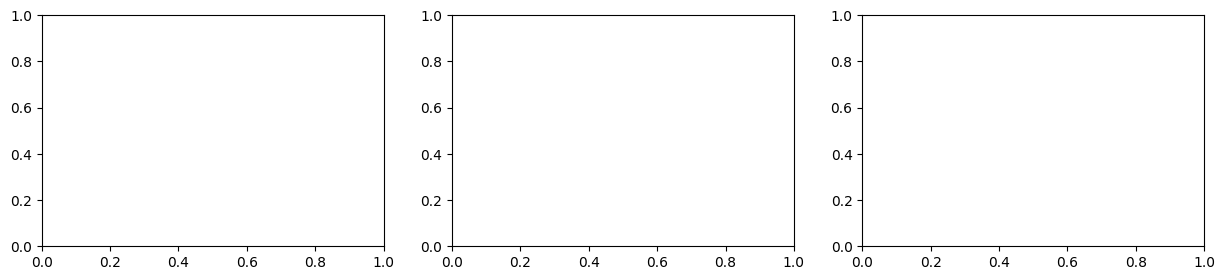

In [49]:
plt.rcParams['figure.figsize'] = [15,3]
fig, ax = plt.subplots(1,3)
ax[0].plot(rho_plot, cr_rho, c='b', label='$\\delta=0$, b=0')
ax[0].plot(rho_plot, cr_rho2, c='b', alpha=0.5, label='$\\delta=0$, b=50')
ax[0].plot(rho_plot, cr_rho3, c='r', alpha=0.8, label='$\\delta \\in$ [40,150], b=50')
ax[0].legend()
#ax[0].set_yscale('log')
ax[0].set_xlabel('$\\eta$ ($\\degree$)')
ax[0].set_ylabel('CRLB$_{\\rho}$ ($\\degree$)')
ax[0].set_ylim((0,22))
ax[0].grid()
ax[1].plot(rho_plot, cr_eta, c='b')
ax[1].plot(rho_plot, cr_eta2, c='b', alpha=0.5)
ax[1].plot(rho_plot, cr_eta3, c='r', alpha=0.8)
#ax[1].axhline(3.6)
#ax[1].set_yscale('log')
ax[1].set_xlabel('$\\eta$ ($\\degree$)')
ax[1].set_ylabel('CRLB$_{\\eta}$ ($\\degree$)')
ax[1].set_ylim((0,22))
ax[1].grid()
#ax[2].plot(eta_plot, cr_delta, c='b')
#ax[2].plot(eta_plot, cr_delta2, c='b', alpha=0.5)
ax[2].plot(rho_plot, cr_delta3, c='r', alpha=0.8)
#ax[2].set_yscale('log')
ax[2].set_xlabel('$\\eta$ ($\\degree$)')
ax[2].set_ylabel('CRLB$_{\\delta}$ ($\\degree$)')
ax[2].set_ylim((0,22))
ax[2].grid()